# Project : SQL + Python Ecommere

 ## installing libraries

In [ ]:
pip install pandas,matplotlib,mysql-connector-python,seaborn

## onverting csv files into SQL

In [ ]:
import pandas as pd
import mysql.connector
import os


# List of CSV files and their corresponding table names
csv_files = [
    ('customers.csv', 'customers'),
    ('orders.csv', 'orders'),
    ('sellers.csv', 'sallers'),
    ('products.csv', 'products'),
    ('geolocation.csv', 'geolocation'),
    ('payments.csv', 'payments'),
    ('order_items.csv','order_items')# Added payments.csv for specific handling
]

# Connect to the MySQL database
conn = mysql.connector.connect(
    host='localhost',
    user='root',
    password='admin',
    database='ecommerce'
)
cursor = conn.cursor()

# Folder containing the CSV files
folder_path = 'C:/Users/DELL/Desktop/data sets/ecommerce'

def get_sql_type(dtype):
    if pd.api.types.is_integer_dtype(dtype):
        return 'INT'
    elif pd.api.types.is_float_dtype(dtype):
        return 'FLOAT'
    elif pd.api.types.is_bool_dtype(dtype):
        return 'BOOLEAN'
    elif pd.api.types.is_datetime64_any_dtype(dtype):
        return 'DATETIME'
    else:
        return 'TEXT'

for csv_file, table_name in csv_files:
    file_path = os.path.join(folder_path, csv_file)
    
    # Read the CSV file into a pandas DataFrame
    df = pd.read_csv(file_path)
    
    # Replace NaN with None to handle SQL NULL
    df = df.where(pd.notnull(df), None)
    
    # Debugging: Check for NaN values
    print(f"Processing {csv_file}")
    print(f"NaN values before replacement:\n{df.isnull().sum()}\n")

    # Clean column names
    df.columns = [col.replace(' ', '_').replace('-', '_').replace('.', '_') for col in df.columns]

    # Generate the CREATE TABLE statement with appropriate data types
    columns = ', '.join([f'`{col}` {get_sql_type(df[col].dtype)}' for col in df.columns])
    create_table_query = f'CREATE TABLE IF NOT EXISTS `{table_name}` ({columns})'
    cursor.execute(create_table_query)

    # Insert DataFrame data into the MySQL table
    for _, row in df.iterrows():
        # Convert row to tuple and handle NaN/None explicitly
        values = tuple(None if pd.isna(x) else x for x in row)
        sql = f"INSERT INTO `{table_name}` ({', '.join(['`' + col + '`' for col in df.columns])}) VALUES ({', '.join(['%s'] * len(row))})"
        cursor.execute(sql, values)

    # Commit the transaction for the current CSV file
    conn.commit()

# Close the connection
conn.close()


In [3]:
import pandas as pd
import mysql.connector
import matplotlib.pyplot as plt
import numpy as np
import seaborn as sns


## database connection 

In [5]:
conn = mysql.connector.connect(
    host='localhost',
    user='root',
    password='admin',
    database='ecommerce'
)
cur = conn.cursor()

### 1) list all uniq cities where customers are located

In [9]:
query='''select distinct customer_city from customers'''

cur.execute(query)
data=cur.fetchall()
df=pd.DataFrame(data,columns=["Cities"])
df.head(10)

,Cities
0,franca
1,sao bernardo do campo
2,sao paulo
3,mogi das cruzes
4,campinas
5,jaragua do sul
6,timoteo
7,curitiba
8,belo horizonte
9,montes claros


### 2) count the number of orders placed in 2017

In [17]:
query='''select count(order_id) from orders where year(order_purchase_timestamp)=2017'''
cur.execute(query)
data=cur.fetchall()
print("Total number of orders placed in 2017 : ",data[0][0])


Total number of orders placed in 2017 :  135303


### 3)find total sales per category

In [14]:
query='''select products.product_category,round(sum(payments.payment_value),2)
from products join order_items
on products.product_id=order_items.product_id
join payments
on payments.order_id = order_items.order_id
group by product_category'''

cur.execute(query)
data=cur.fetchall()
df=pd.DataFrame(data,columns=["Category","Sales"])
df

,Category,Sales
0,perfumery,506738.66
1,Furniture Decoration,1430176.39
2,telephony,486882.05
3,bed table bath,1712553.67
4,automotive,852294.33
...,...,...
69,cds music dvds,1199.43
70,La Cuisine,2913.53
71,Fashion Children's Clothing,785.67
72,PC Gamer,2174.43


### 4)calculate the percentage of order that were paid in installments

In [21]:
query='''select (sum(case when payment_installments>=1 then 1 else 0 end))/count(*)*100 from payments'''
cur.execute(query)
data=cur.fetchall()
print("Percentage : ",data[0][0],"%")

Percentage :  99.9981 %


### 5)count total number of customers from each state

   State  Customer_Count
0     SP          125238
1     SC           10911
2     MG           34905
3     PR           15135
4     RJ           38556
5     RS           16398
6     PA            2925
7     GO            6060
8     ES            6099
9     BA           10140
10    MA            2241
11    MS            2145
12    CE            4008
13    DF            6420
14    RN            1455
15    PE            4956
16    MT            2721
17    AM             444
18    AP             204
19    AL            1239
20    RO             759
21    PB            1608
22    TO             840
23    PI            1485
24    AC             243
25    SE            1050
26    RR             138


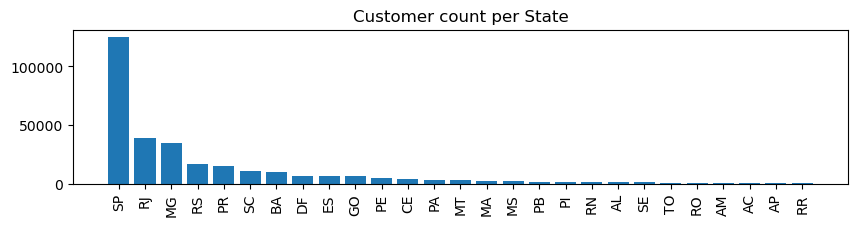

In [56]:
query='''select customer_state,count(customer_id) from customers group by customer_state'''
cur.execute(query)
data=cur.fetchall()
df=pd.DataFrame(data,columns=["State","Customer_Count"])
print(df)

df=df.sort_values(by="Customer_Count",ascending=False)

plt.figure(figsize=(10,2))
plt.bar(df["State"],df["Customer_Count"])
plt.title("Customer count per State")
plt.xticks(rotation=90)
plt.show()

### 6) calculate the orders per month in 2018

       Month  Total_orders
0       July         18876
1     August         19536
2   February         20184
3       June         18501
4      March         21633
5    January         21807
6        May         20619
7      April         20817
8  September            48
9    October            12


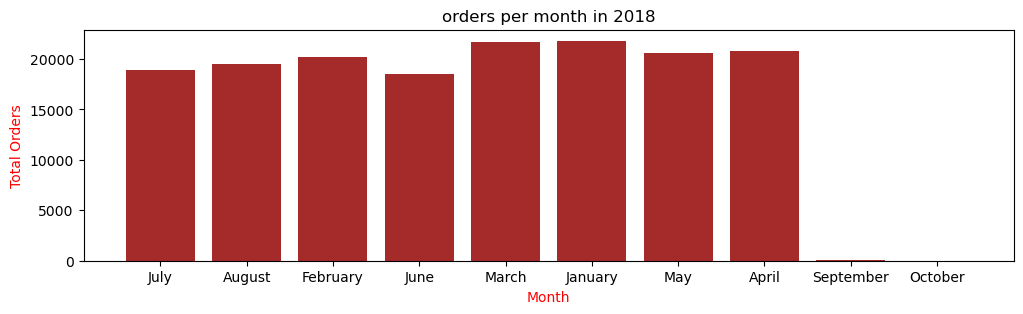

In [54]:
query='''select monthname(order_purchase_timestamp) months,count(order_id) order_count 
from orders 
where year(order_purchase_timestamp)=2018 
group by months '''

cur.execute(query)
data=cur.fetchall()
df=pd.DataFrame(data,columns=["Month","Total_orders"])
print(df)
o=['January','February','March','April','May','June','July','August','September','Octomber']
plt.figure(figsize=(12,3))
plt.bar(df["Month"],df["Total_orders"],color="brown")
plt.title("orders per month in 2018")
plt.xlabel("Month",color="red")
plt.ylabel("Total Orders",color="red")
plt.show()

### 7) find the avrage number of products per order group by customer city

In [61]:
query='''with count_per_order as (select orders.order_id, orders.customer_id,count(order_items.order_id) as oc 
from orders join order_items 
on orders.order_id=order_items.order_id
group by orders.order_id,orders.customer_id)  
select customers.customer_city,round(avg(count_per_order.oc),2) 
from customers join count_per_order 
on customers.customer_id=count_per_order.customer_id 
group by customers.customer_city
'''

cur.execute(query)
data=cur.fetchall()

df=pd.DataFrame(data,columns=["City","Avrage_Number_of_products"])
df.head()

,City,Avrage_Number_of_products
0,treze tilias,3.82
1,indaial,3.35
2,sao jose dos campos,3.42
3,sao paulo,3.47
4,porto alegre,3.52


### 8) calculate percentage of total revenue contributed by each product category

In [65]:
query='''select products.product_category,round((sum(payments.payment_value)/(select sum(payment_value) from payments))*100,2 ) as sales
from products join order_items
on products.product_id=order_items.product_id
join payments
on payments.order_id = order_items.order_id
group by product_category order by sales desc'''

cur.execute(query)
data=cur.fetchall()

df=pd.DataFrame(data,columns=["Product_Category","Percentage_contribute"])
df


,Product_Category,Percentage_contribute
0,bed table bath,10.70
1,HEALTH BEAUTY,10.35
2,computer accessories,9.90
3,Furniture Decoration,8.93
4,Watches present,8.93
...,...,...
69,House Comfort 2,0.01
70,cds music dvds,0.01
71,PC Gamer,0.01
72,Fashion Children's Clothing,0.00


### 9) Identify the correlation between product price and the number of times a product has been purchesed 

In [74]:
query='''select products.product_category,count(order_items.order_id),
round(avg(order_items.price),2)
from products join order_items
on products.product_id=order_items.product_id
group by products.product_category;'''

cur.execute(query)
data=cur.fetchall()

df=pd.DataFrame(data,columns=["Category","count_of_orders","avrage_price"])
arr1=df["count_of_orders"]
arr2=df["avrage_price"]
print(np.corrcoef([arr1,arr2]))
print("Here correlation coefficient is approximetly nutral so there is no impact on product price over count of purches")

[[ 1.         -0.10631514]
 [-0.10631514  1.        ]]
Here correlation coefficient is approximetly nutral so there is no impact on product price over count of purches


### 10) calculate total revenue generated by each seller , and rank them by revenue

In [78]:
query='''select *,dense_rank() over(order by revenue desc) as rn
from 
(select order_items.seller_id,round(sum(payments.payment_value)) as revenue
from order_items join payments
on order_items.order_id=payments.order_id
group by order_items.seller_id) as a'''

cur.execute(query)
data=cur.fetchall()

df=pd.DataFrame(data,columns=["Seller_id","Revenue","Rank"])
df

,Seller_id,Revenue,Rank
0,7c67e1448b00f6e969d365cea6b010ab,507167.0,1
1,1025f0e2d44d7041d6cf58b6550e0bfa,308222.0,2
2,4a3ca9315b744ce9f8e9374361493884,301245.0,3
3,1f50f920176fa81dab994f9023523100,290253.0,4
4,53243585a1d6dc2643021fd1853d8905,284903.0,5
...,...,...,...
3090,ad14615bdd492b01b0d97922e87cb87f,19.0,2236
3091,702835e4b785b67a084280efca355756,19.0,2236
3092,4965a7002cca77301c82d3f91b82e1a9,16.0,2237
3093,77128dec4bec4878c37ab7d6169d6f26,15.0,2238


### 11)calculate the moving avrage of order values for each customer over there order history

In [80]:
query='''select customer_id,order_purchase_timestamp,payment,
avg(payment) over(partition by customer_id order by order_purchase_timestamp
rows between 2 preceding and current row) as mov_avg
from
(select orders.customer_id,orders.order_purchase_timestamp,
payments.payment_value as payment
from 
payments join orders
on payments.order_id=orders.order_id) as a'''

cur.execute(query)
data=cur.fetchall()

df=pd.DataFrame(data,columns=["customer_id","order_purches_time","payment","moving_avg"])
df.head()

,customer_id,order_purches_time,payment,moving_avg
0,00012a2ce6f8dcda20d059ce98491703,2017-11-14 16:08:26,114.74,114.739998
1,00012a2ce6f8dcda20d059ce98491703,2017-11-14 16:08:26,114.74,114.739998
2,00012a2ce6f8dcda20d059ce98491703,2017-11-14 16:08:26,114.74,114.739998
3,000161a058600d5901f007fab4c27140,2017-07-16 09:40:32,67.41,67.410004
4,000161a058600d5901f007fab4c27140,2017-07-16 09:40:32,67.41,67.410004


### 12) calculate the cumulative sales per month for each year

In [6]:
query='''select years,months,payment,sum(payment) over(order by years,months) as cumulative_sales
from
(select year(orders.order_purchase_timestamp) as years,
month(orders.order_purchase_timestamp) as months,
round(sum(payments.payment_value),2) as payment
from orders join payments
on orders.order_id=payments.order_id
group by years,months) as a'''

cur.execute(query)
data=cur.fetchall()

df=pd.DataFrame(data,columns=["year","month","payment","cumulative_sales"])
df

,year,month,payment,cumulative_sales
0,2016,9,756.72,756.72
1,2016,10,177271.44,178028.16
2,2016,12,58.86,178087.02
3,2017,1,415464.12,593551.14
4,2017,2,875724.03,1469275.17
5,2017,3,1349590.80,2818865.97
6,2017,4,1253364.09,4072230.06
7,2017,5,1778756.46,5850986.52
8,2017,6,1533829.14,7384815.66
9,2017,7,1777148.76,9161964.42


### 13) calculate year-over-year growth rate of total sales

#### formula =((current_sales-privious_sales)/perivios_sales) * 100    - percentage 

In [7]:
query='''
with a as(select year(orders.order_purchase_timestamp) as years,
round(sum(payments.payment_value),2) as payment
from orders join payments
on orders.order_id=payments.order_id
group by years)
select years,round(((payment-lag(payment,1) over(order by years))/lag(payment,1) over(order by years))*100) from a
'''
cur.execute(query)
data=cur.fetchall()

df=pd.DataFrame(data,columns=["years","yoy % growth"])
df

,years,yoy % growth
0,2016,NaN
1,2017,12113.0
2,2018,20.0


### 14) Calculate retenstion rate of customers, define as the percentage of customers who make another purchase with in 6 months of there first purches

In [8]:
query='''with a as (
    select customers.customer_id,
    min(orders.order_purchase_timestamp) first_order
    from customers join orders
    on customers.customer_id=orders.customer_id
    group by customers.customer_id),

    b as(
    select a.customer_id,count(distinct orders.order_purchase_timestamp) next_order
    from a join orders
    on orders.customer_id=a.customer_id
    and orders.order_purchase_timestamp > first_order
    and orders.order_purchase_timestamp<date_add(first_order, interval 6 month)
    group by a.customer_id)

    select 100 * (count(distinct a.customer_id)/count(distinct b.customer_id))
    from a left join b
    on a.customer_id=b.customer_id
'''

cur.execute(query)
data=cur.fetchall()
data


# as we don't have and repeat orders so it will does not give any values

# df=pd.DataFrame(data,columns=["City","Avrage_Number_of_products"])
# df.head()

[(None,)]

### 15) Identify top 3 customers who spent the most money in each year 

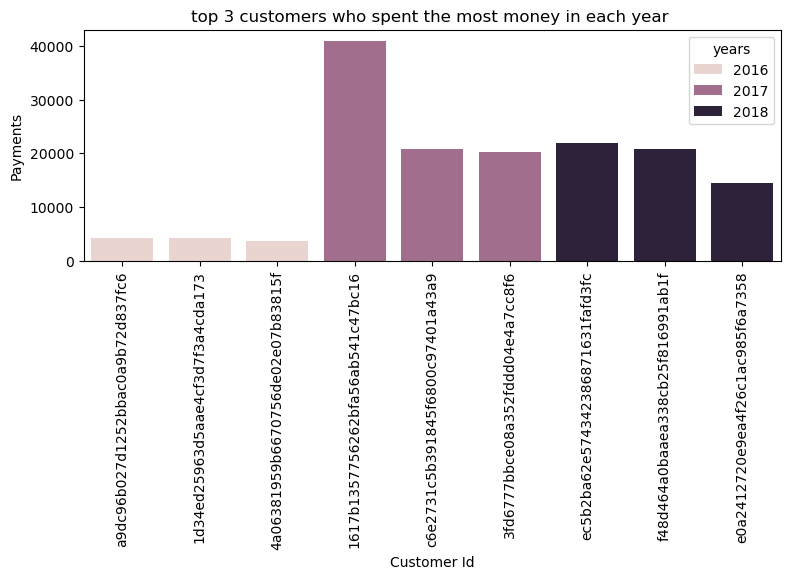

In [7]:
query='''
select years,customer_id,payment,d_rank
from
(
select year(orders.order_purchase_timestamp) years,
orders.customer_id,
sum(payments.payment_value) payment,
dense_rank() over(partition by year(orders.order_purchase_timestamp) order by sum(payments.payment_value) desc) d_rank
from orders join payments
on payments.order_id=orders.order_id
group by year(orders.order_purchase_timestamp),orders.customer_id
) as a
where d_rank<=3
'''
cur.execute(query)
data=cur.fetchall()

df=pd.DataFrame(data,columns=["years","id","payment","d_rank"])
plt.figure(figsize=(9,3))
sns.barplot(x="id",y="payment",data=df,hue="years")
plt.title("top 3 customers who spent the most money in each year ")
plt.xlabel("Customer Id")
plt.ylabel("Payments")
plt.xticks(rotation=90)
plt.show()